In [1]:
import pandas as pd

df = pd.read_csv('final_data_cleaned.csv')


df.columns = df.columns.str.strip().str.lower()

In [2]:
df_new = df.copy()

In [3]:
df_new['income_loan_ratio'] = df_new['income'] / (df_new['loanamount'] + 1)

df_new['credit_income_ratio'] = df_new['creditscore'] / (df_new['income'] + 1)

df_new['loan_dti_interaction'] = df_new['loanamount'] * df_new['dtiratio']

In [4]:
df_new['high_dti_flag'] = (df_new['dtiratio'] > 0.4).astype(int)

df_new['low_credit_flag'] = (df_new['creditscore'] < 600).astype(int)

df_new['high_loan_flag'] = (df_new['loanamount'] > df_new['loanamount'].median()).astype(int)

In [6]:
print((df_new['income'] < 0).sum())
print((df_new['loanamount'] < 0).sum())

127749
127699


In [7]:
df_new['income'] = df_new['income'].clip(lower=0)
df_new['loanamount'] = df_new['loanamount'].clip(lower=0)

In [8]:
df_new['income'] = df_new['income'].clip(lower=0)
df_new['loanamount'] = df_new['loanamount'].clip(lower=0)

In [9]:
import numpy as np

df_new['log_income'] = np.log1p(df_new['income'])
df_new['log_loanamount'] = np.log1p(df_new['loanamount'])

In [10]:
X = df_new.drop('default', axis=1)
y = df_new['default']

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [14]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42
)

lgbm.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 23805, number of negative: 180472
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005276 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1315
[LightGBM] [Info] Number of data points in the train set: 204277, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [15]:
from sklearn.metrics import roc_auc_score

y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
y_prob_lgbm = lgbm.predict_proba(X_test)[:, 1]

print("New XGBoost AUC:", roc_auc_score(y_test, y_prob_xgb))
print("New LightGBM AUC:", roc_auc_score(y_test, y_prob_lgbm))

New XGBoost AUC: 0.7572120947511656
New LightGBM AUC: 0.75608026016779


In [16]:
print("Logistic Regression AUC: 0.7511")
print(" XGBoost AUC:", roc_auc_score(y_test, y_prob_xgb))
print(" LightGBM AUC:", roc_auc_score(y_test, y_prob_lgbm))

Logistic Regression AUC: 0.7511
 XGBoost AUC: 0.7572120947511656
 LightGBM AUC: 0.75608026016779


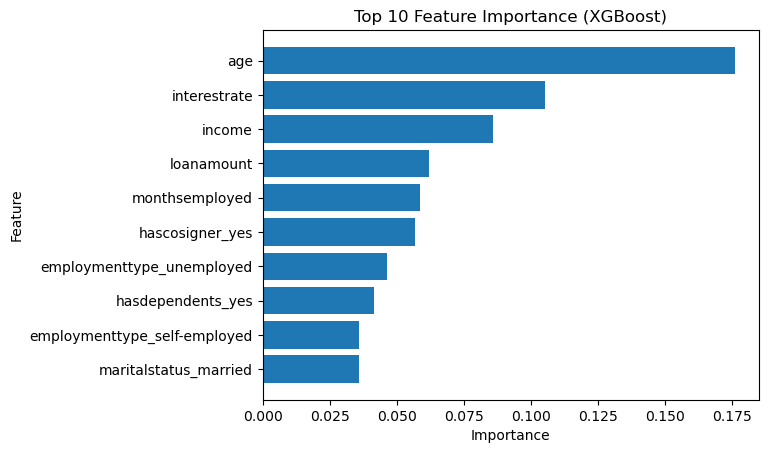

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

# Create importance dataframe
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Take top 10 features
top_features = importance.head(10)

# Plot
plt.figure()
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance (XGBoost)")
plt.gca().invert_yaxis()
plt.show()